# Phase2: Model

In [1]:
import os
import numpy as np
import pandas as pd
import analytics
import ml_utilities
import operators_library
import data_helpers
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from hmmlearn.hmm import GaussianHMM

## 2.1 Feature Set Engineering

In [2]:
x_path = Path('data') / 'X_core_weekly.parquet'
X_core = pd.read_parquet(x_path)

In [3]:
X_core.tail()

,DFII10,ICSA,VIX,NFCI,ANFCI,T10YIE,T10Y3M,EPU,HY_OAS,GDPNow
date,,,,,,,,,,
2026-01-30,1.90,209000.0,17.44,-0.55645,-0.58009,2.36,0.59,211.46,2.80,4.2
2026-02-06,1.88,232000.0,17.76,-0.55053,-0.56771,2.34,0.54,176.18,2.87,4.2
2026-02-13,1.77,229000.0,20.60,-0.54241,-0.55397,2.27,0.36,337.58,2.95,3.6
2026-02-20,1.80,208000.0,19.09,-0.53309,-0.54142,2.28,0.39,474.58,2.86,3.0
2026-02-27,1.72,213000.0,19.86,-0.52365,-0.53018,2.25,0.30,325.41,3.10,3.0


### Growth bucket: GDPNow, ICSA
### Rates/inflation bucket: T10YIE, DFII10, T10Y3M
### Stress bucket: NFCI or ANFCI, HY_OAS, VIX, EPU

In [4]:
def make_core_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Raw economically signed features from X_core_weekly.

    Sign convention:
    - growth_*: higher = stronger growth
    - rates_*: higher = more inflation / policy / late-cycle pressure
    - stress_*: higher = more financial stress / tighter conditions
    """
    X = X.copy().sort_index()

    out = pd.DataFrame(index=X.index)

    # ---------- Growth bucket ----------
    # GDPNow: higher = stronger growth
    out["growth_gdpnow_lvl"] = X["GDPNow"]
    out["growth_gdpnow_d4"] = X["GDPNow"].diff(4)

    # Initial claims: higher = worse growth, so flip sign
    icsa_log = np.log(X["ICSA"])
    out["growth_claims_lvl"] = -icsa_log
    out["growth_claims_d4"] = -icsa_log.diff(4)

    # ---------- Rates / inflation-pressure bucket ----------
    # Breakevens: higher = more inflation pressure
    out["rates_breakeven_lvl"] = X["T10YIE"]
    out["rates_breakeven_d4"] = X["T10YIE"].diff(4)

    # Real yield: higher = tighter real-rate pressure
    out["rates_real_yield_lvl"] = X["DFII10"]
    out["rates_real_yield_d4"] = X["DFII10"].diff(4)

    # Curve slope: lower / more inverted = more late-cycle / tighter pressure, so flip sign
    out["rates_curve_inv_lvl"] = -X["T10Y3M"]
    out["rates_curve_inv_d4"] = -X["T10Y3M"].diff(4)

    # ---------- Stress / liquidity bucket ----------
    # Use ANFCI in baseline, not both NFCI and ANFCI
    out["stress_anfci_lvl"] = X["ANFCI"]
    out["stress_anfci_d4"] = X["ANFCI"].diff(4)

    hy_log = np.log(X["HY_OAS"])
    out["stress_hy_oas_lvl"] = hy_log
    out["stress_hy_oas_d4"] = hy_log.diff(4)

    vix_log = np.log(X["VIX"])
    out["stress_vix_lvl"] = vix_log
    out["stress_vix_d4"] = vix_log.diff(4)

    epu_log = np.log(X["EPU"])
    out["stress_epu_lvl"] = epu_log
    out["stress_epu_d4"] = epu_log.diff(4)

    return out

In [5]:
def build_bucket_scores(Z: pd.DataFrame) -> pd.DataFrame:
    """
    Build parsimonious bucket composites from standardized features.
    Output sign convention:
    - growth: higher = stronger growth
    - rates_pressure: higher = more inflation / rate / inversion pressure
    - stress: higher = more financial stress
    """
    B = pd.DataFrame(index=Z.index)

    growth_cols = [
        "growth_gdpnow_lvl",
        "growth_gdpnow_d4",
        "growth_claims_lvl",
        "growth_claims_d4",
    ]

    rates_cols = [
        "rates_breakeven_lvl",
        "rates_breakeven_d4",
        "rates_real_yield_lvl",
        "rates_real_yield_d4",
        "rates_curve_inv_lvl",
        "rates_curve_inv_d4",
    ]

    stress_cols = [
        "stress_anfci_lvl",
        "stress_anfci_d4",
        "stress_hy_oas_lvl",
        "stress_hy_oas_d4",
        "stress_vix_lvl",
        "stress_vix_d4",
        "stress_epu_lvl",
        "stress_epu_d4",
    ]

    B["growth"] = Z[growth_cols].mean(axis=1)
    B["rates_pressure"] = Z[rates_cols].mean(axis=1)
    B["stress"] = Z[stress_cols].mean(axis=1)

    # optional: short-horizon bucket momentum
    B["growth_d4"] = B["growth"].diff(4)
    B["rates_pressure_d4"] = B["rates_pressure"].diff(4)
    B["stress_d4"] = B["stress"].diff(4)

    return B

In [6]:
X_feat_raw = make_core_engineered_features(X_core)
X_feat_z = data_helpers.rolling_zscore(X_feat_raw, window=104, min_periods=52, clip=4.0)
X_bucket = build_bucket_scores(X_feat_z)

# baseline model inputs: start with only the 3 bucket levels
X_model_3 = X_bucket[["growth", "rates_pressure", "stress"]].dropna().copy()

# richer but still compact version: add bucket momentum
X_model_6 = X_bucket[
    ["growth", "rates_pressure", "stress",
     "growth_d4", "rates_pressure_d4", "stress_d4"]
].dropna().copy()

In [7]:
X_model_3.tail()

,growth,rates_pressure,stress
date,,,
2026-01-30,0.581064,-0.013692,-0.266149
2026-02-06,-0.513366,-0.080765,-0.049563
2026-02-13,-0.765823,-0.494528,0.491179
2026-02-20,0.057639,-0.429597,0.462238
2026-02-27,0.034139,-0.632517,0.573092


In [8]:
# raw engineered feature correlation
corr_raw = X_feat_raw.corr()

# bucket correlation
corr_bucket = X_model_3.corr()

print(corr_bucket)

                  growth  rates_pressure    stress
growth          1.000000        0.317053 -0.258282
rates_pressure  0.317053        1.000000 -0.228930
stress         -0.258282       -0.228930  1.000000


<Axes: title={'center': 'Bucket Features'}, xlabel='date'>

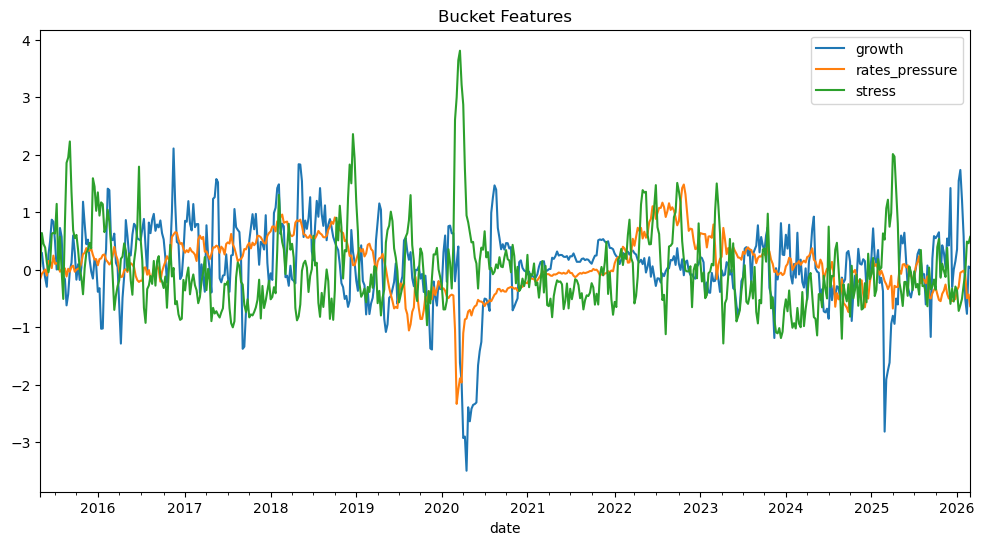

In [9]:
X_model_3.plot(figsize=(12, 6), title="Bucket Features")

## 2.2 Baseline HMM

### Run Benchmark Stack

In [10]:
# ensure no missing values
X_bench = X_model_3.dropna().copy()

gmm_results, gmm_models = data_helpers.fit_gmm_grid(
    X_bench,
    ks=(2, 3, 4),
    n_init=50,
    random_state=42
)

hmm_results, hmm_models = data_helpers.fit_hmm_grid(
    X_bench,
    ks=(2, 3, 4),
    covariance_type="diag",
    seeds=range(30),
    n_iter=2000,
    tol=1e-4
)

print("GMM results")
display(gmm_results)

print("HMM results")
display(hmm_results)

Model is not converging.  Current: -934.424147809941 is not greater than -934.4241439793624. Delta is -3.8305786347336834e-06


GMM results


,model,k,loglik,aic,bic,silhouette
0,GMM,2,-1363.516889,2765.033778,2847.467065,0.428523
1,GMM,3,-1318.075225,2694.150450,2819.969678,0.317073
2,GMM,4,-1300.874204,2679.748409,2848.953578,0.322769


HMM results


,model,k,best_seed,loglik,aic,bic
0,HMM,2,29,-1279.319119,2588.638239,2653.717150
1,HMM,3,5,-1060.757628,2173.515255,2286.318701
2,HMM,4,5,-903.348934,1884.697868,2053.903037


### Diagnostics

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.198630,0.043504,-0.252239,0.563332,0.373615,0.402260,439,0.775618,17.560000,10.0,87,25
1,-0.040213,0.472813,0.787062,0.446739,0.445914,0.574611,107,0.189046,4.458333,2.0,17,24
2,-1.778772,-0.947461,1.574675,1.153186,0.629585,1.201654,20,0.035336,5.000000,2.5,14,4


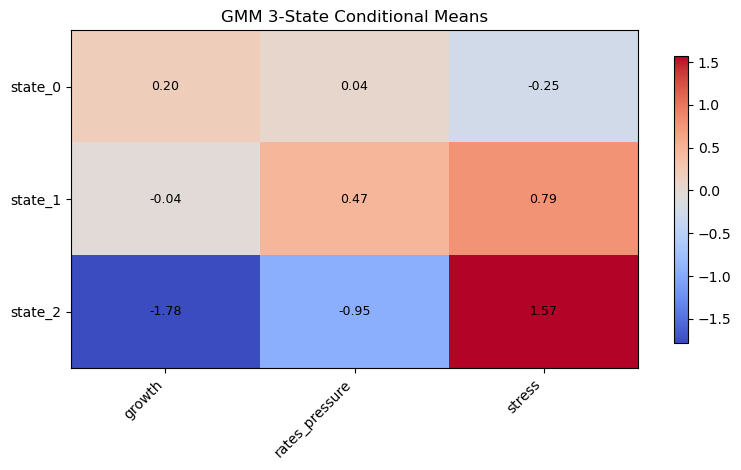

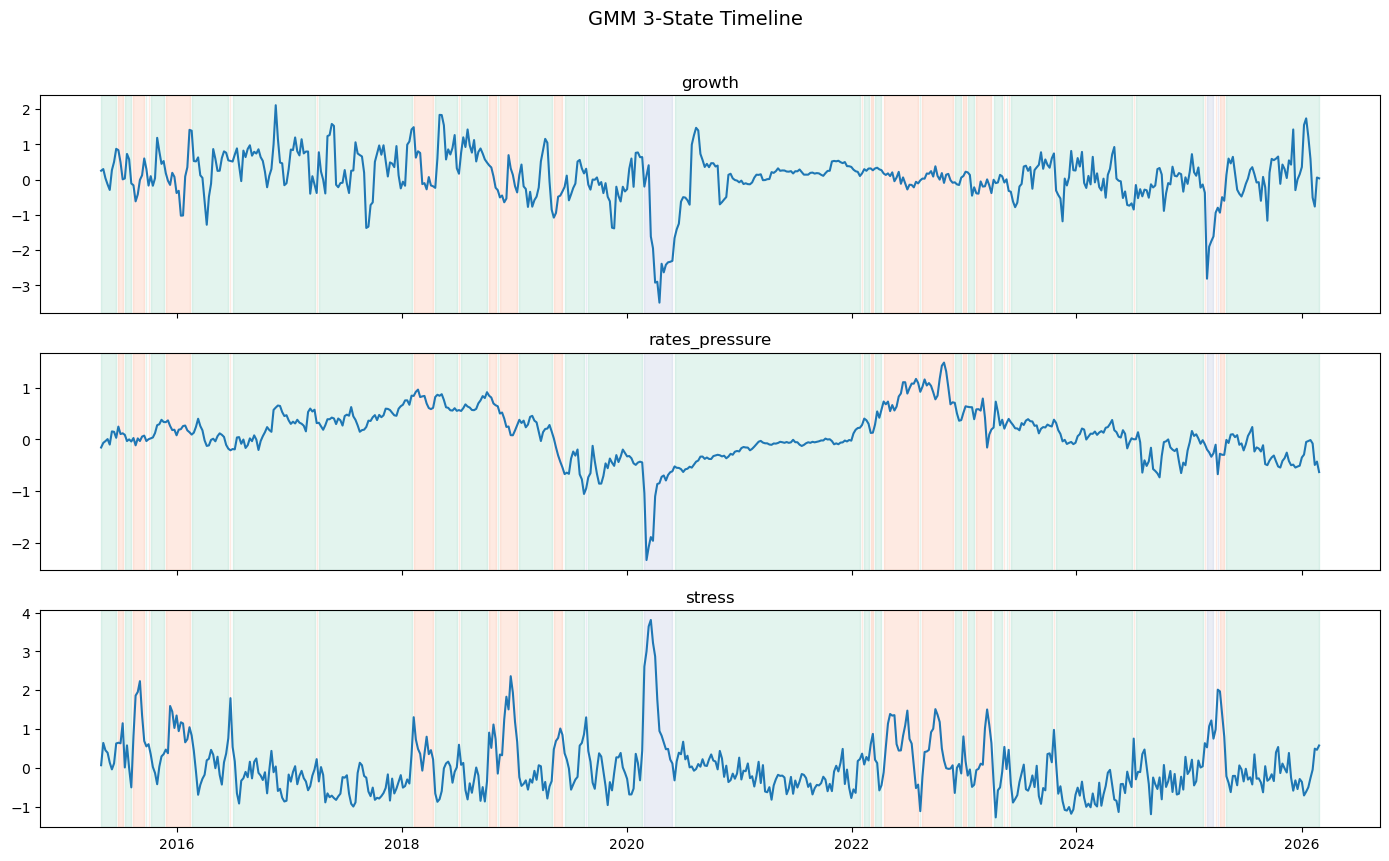

In [11]:
gmm3 = gmm_models[3]

display(gmm3["summary"])
data_helpers.plot_state_means(gmm3["summary"], title="GMM 3-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, gmm3["labels"], title="GMM 3-State Timeline")

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.160656,-0.121392,-0.204311,0.474201,0.218361,0.421254,270,0.477032,24.545455,13.0,77,11
1,0.244233,0.505497,0.031464,0.568109,0.278141,0.676297,238,0.420495,79.333333,93.0,124,3
2,-0.934208,-0.634353,0.907789,1.003740,0.480456,1.040224,58,0.102473,8.285714,8.0,22,7


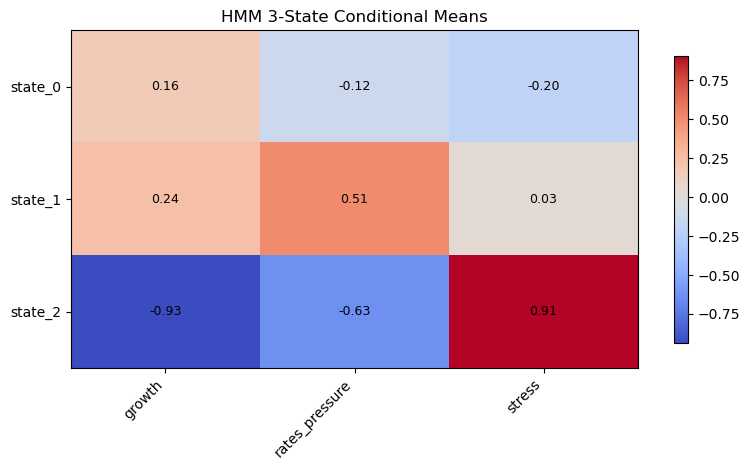

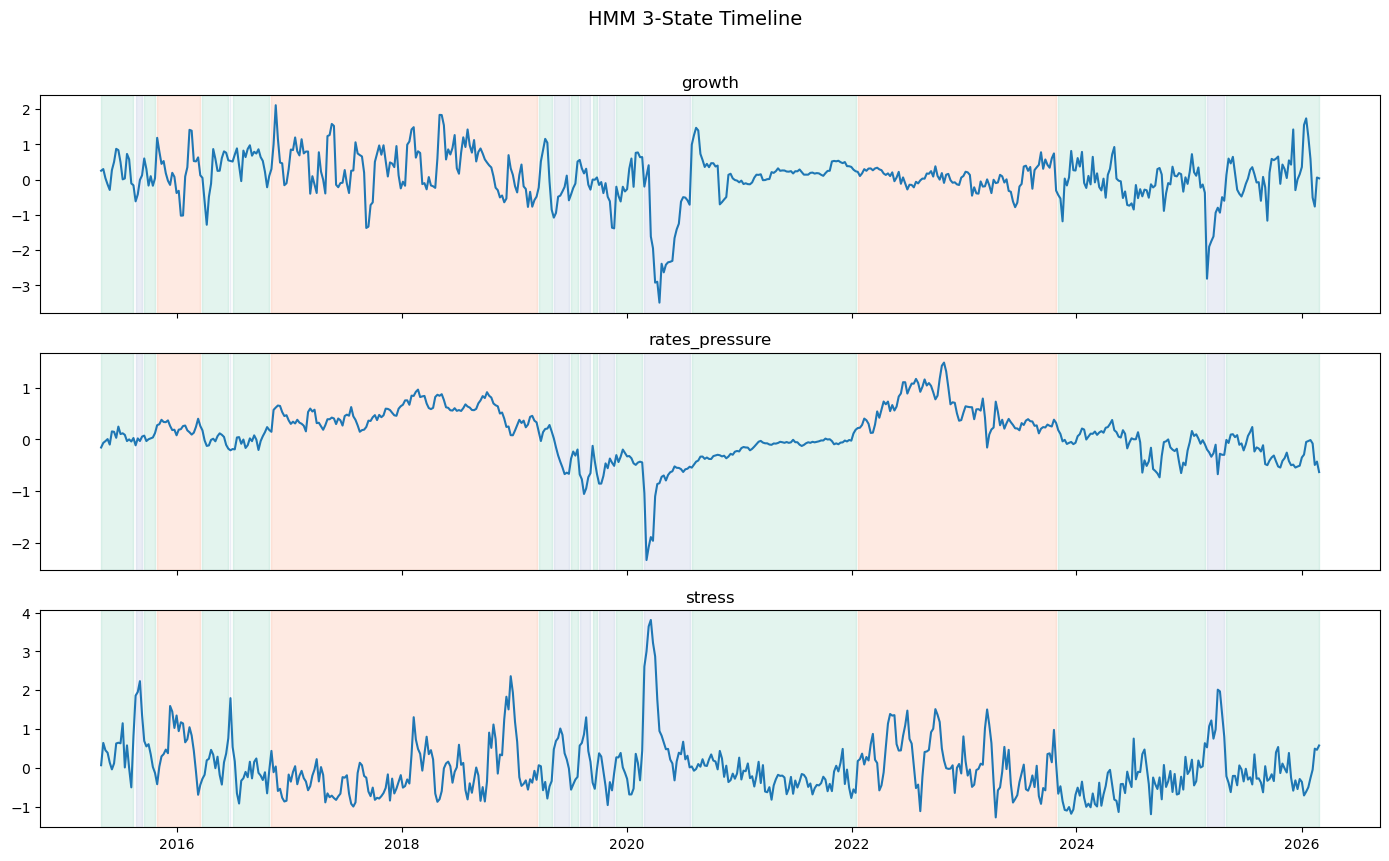

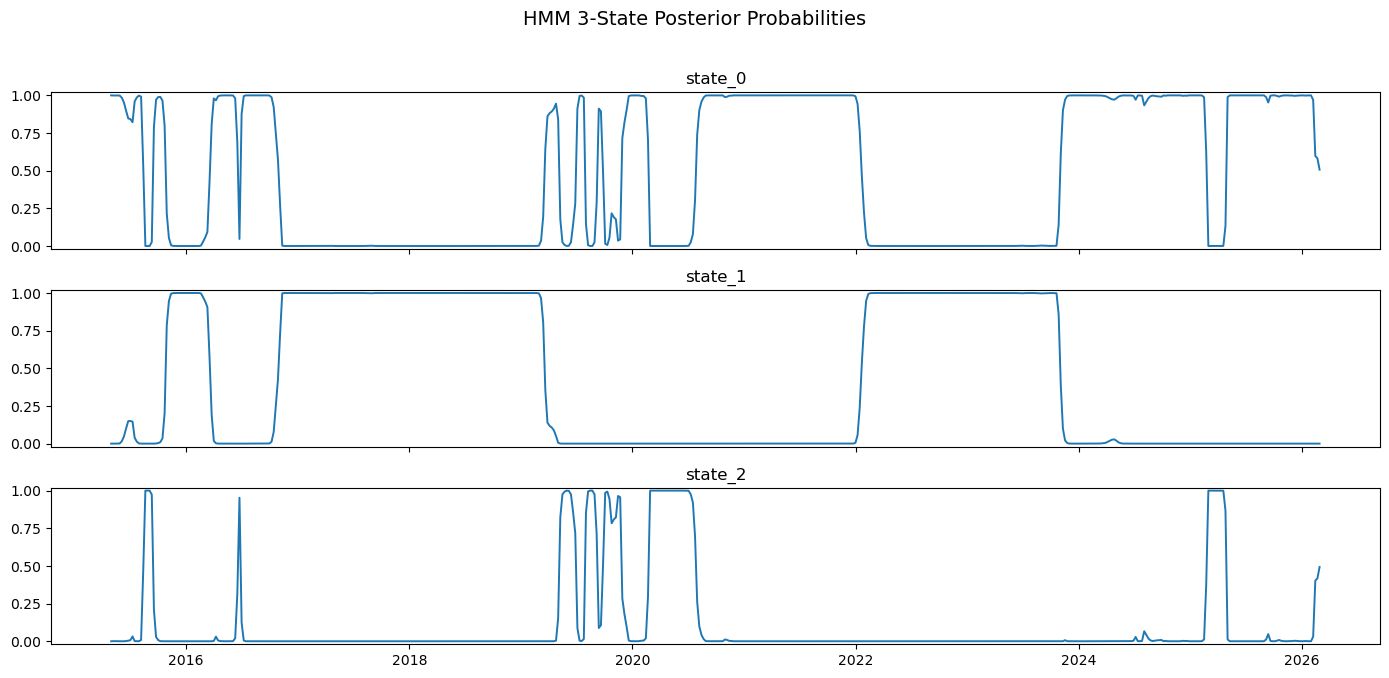

In [12]:
hmm3 = hmm_models[3]

display(hmm3["summary"])
data_helpers.plot_state_means(hmm3["summary"], title="HMM 3-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, hmm3["labels"], title="HMM 3-State Timeline")
data_helpers.plot_hmm_posteriors(hmm3["probs"], title="HMM 3-State Posterior Probabilities")

,growth_mean,rates_pressure_mean,stress_mean,growth_std,rates_pressure_std,stress_std,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,,,,,,,
0,0.158779,-0.002506,-0.237915,0.456331,0.118031,0.439398,192,0.339223,17.454545,13.0,54,11
1,-0.020632,-0.445500,-0.028732,0.607518,0.153478,0.416529,107,0.189046,15.285714,13.0,31,7
2,0.244000,0.507016,0.029767,0.569300,0.277739,0.677220,237,0.418728,79.000000,93.0,123,3
3,-1.292852,-0.709101,1.555850,1.198682,0.639056,1.014129,30,0.053004,6.000000,4.0,14,5


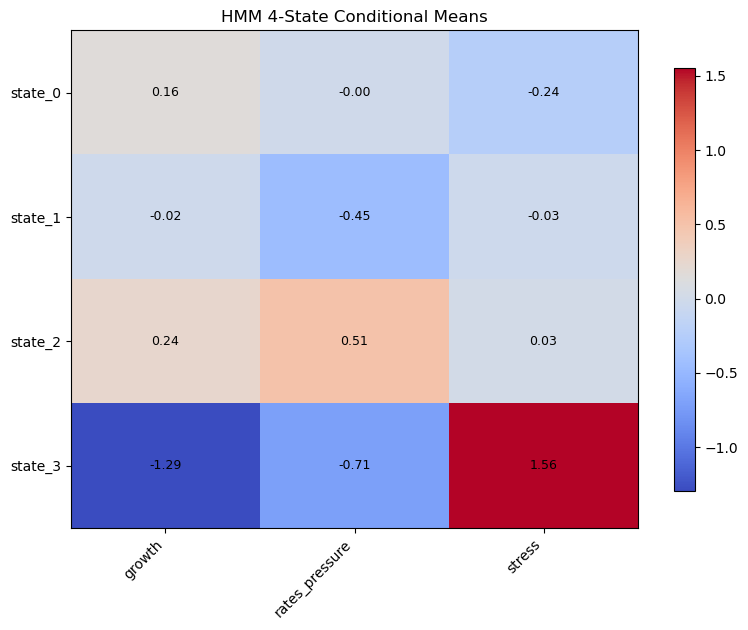

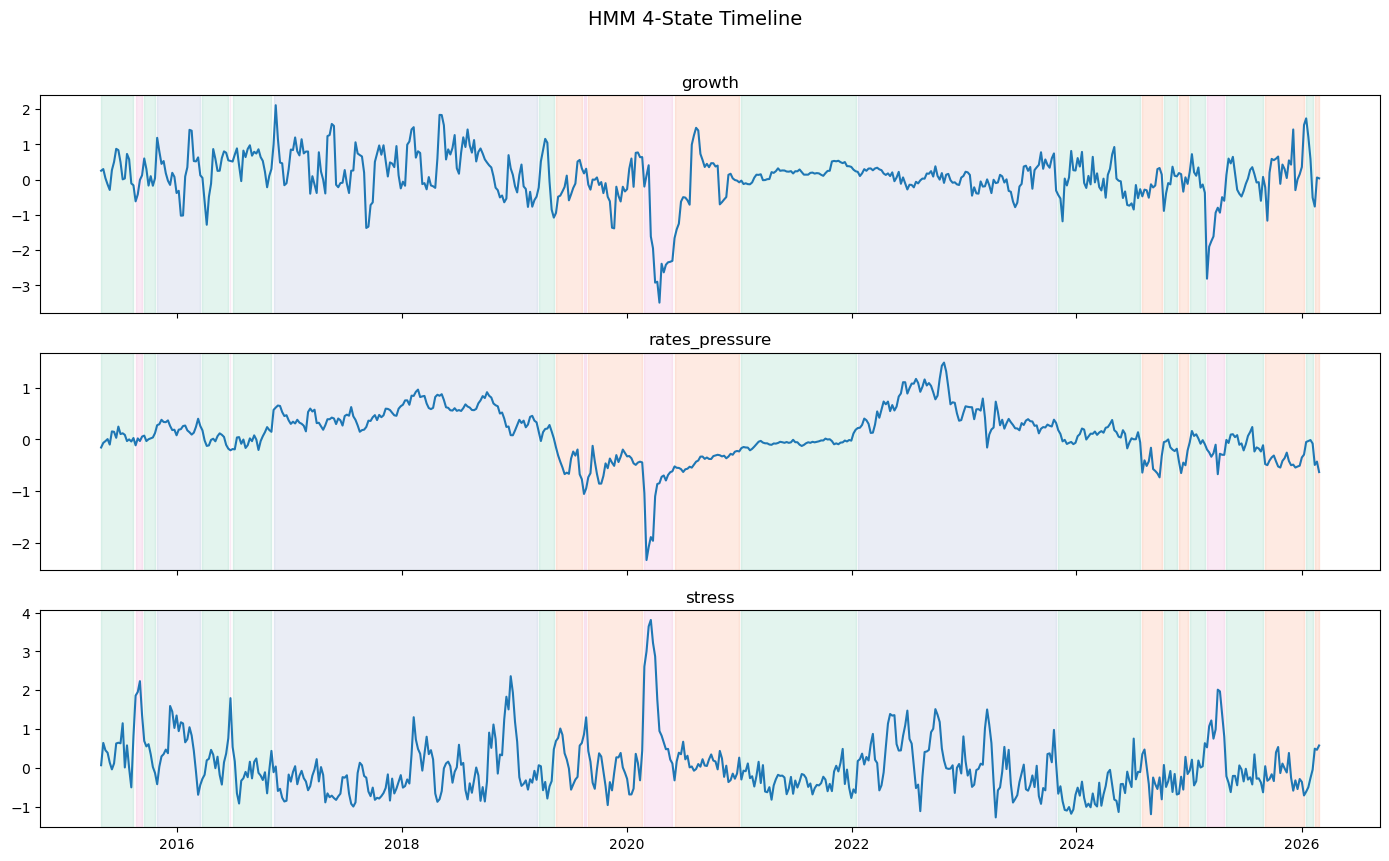

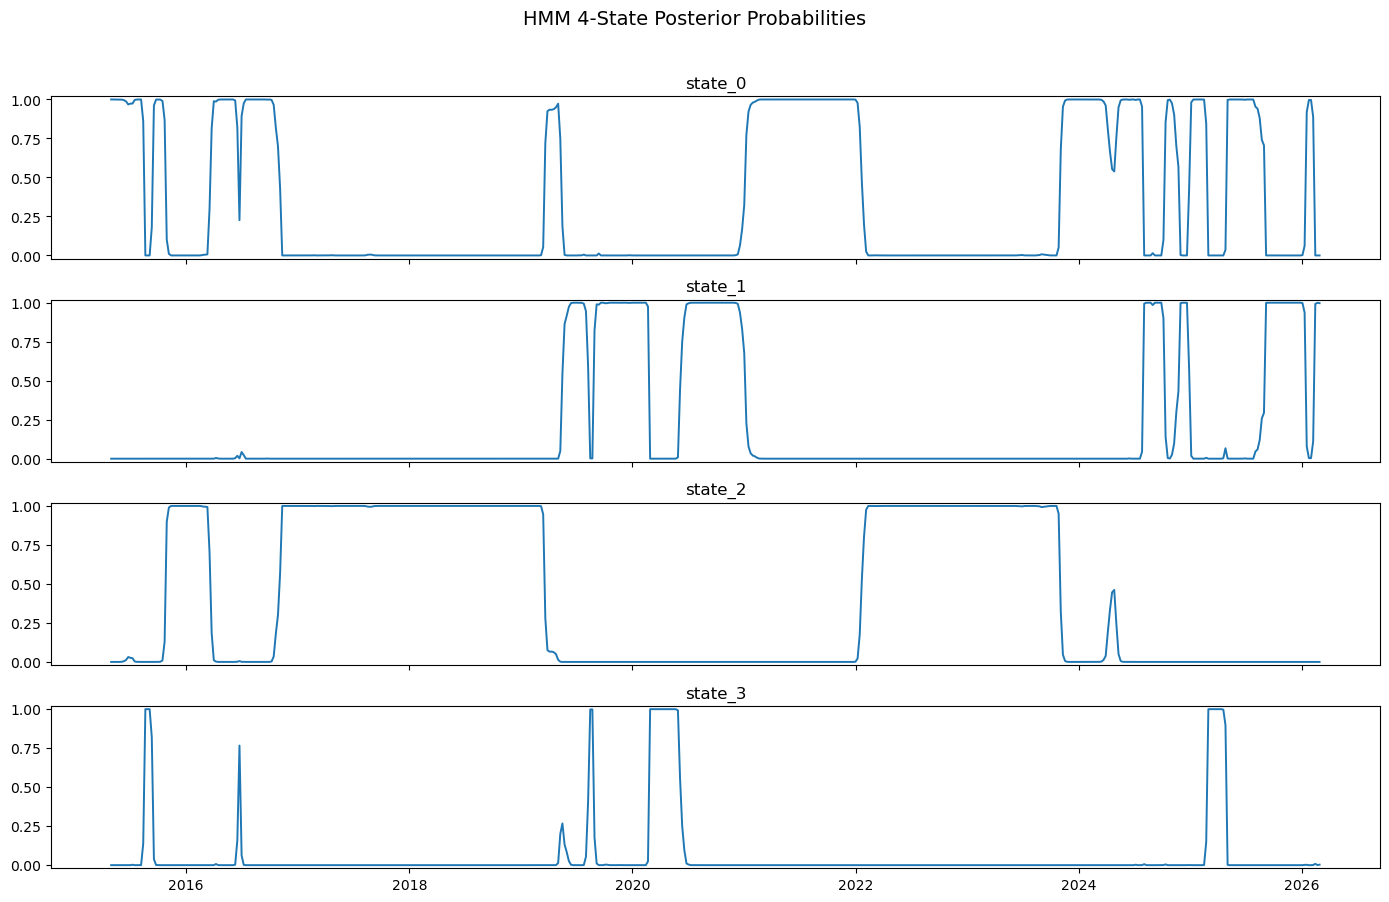

In [13]:
hmm4 = hmm_models[4]

display(hmm4["summary"])
data_helpers.plot_state_means(hmm4["summary"], title="HMM 4-State Conditional Means")
data_helpers.plot_regime_timeline(X_bench, hmm4["labels"], title="HMM 4-State Timeline")
data_helpers.plot_hmm_posteriors(hmm4["probs"], title="HMM 4-State Posterior Probabilities")

In [14]:
print("GMM 3-state")
display(data_helpers.compact_regime_report(gmm_models[3]["summary"]))

print("HMM 3-state")
display(data_helpers.compact_regime_report(hmm_models[3]["summary"]))

print("HMM 4-state")
display(data_helpers.compact_regime_report(hmm_models[4]["summary"]))

GMM 3-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.198630,0.043504,-0.252239,0.775618,17.560000,10.0,25
1,-0.040213,0.472813,0.787062,0.189046,4.458333,2.0,24
2,-1.778772,-0.947461,1.574675,0.035336,5.000000,2.5,4


HMM 3-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.160656,-0.121392,-0.204311,0.477032,24.545455,13.0,11
1,0.244233,0.505497,0.031464,0.420495,79.333333,93.0,3
2,-0.934208,-0.634353,0.907789,0.102473,8.285714,8.0,7


HMM 4-state


,growth_mean,rates_pressure_mean,stress_mean,occupancy,avg_duration,median_duration,n_runs
state,,,,,,,
0,0.158779,-0.002506,-0.237915,0.339223,17.454545,13.0,11
1,-0.020632,-0.445500,-0.028732,0.189046,15.285714,13.0,7
2,0.244000,0.507016,0.029767,0.418728,79.000000,93.0,3
3,-1.292852,-0.709101,1.555850,0.053004,6.000000,4.0,5


,state_0,state_1,state_2
state_0,0.957734,1.214040e-02,3.012515e-02
state_1,0.013432,9.865682e-01,1.138445e-17
state_2,0.123304,9.737198e-21,8.766956e-01


state_0    23.659929
state_1    74.450408
state_2     8.110014
Name: implied_duration, dtype: float64

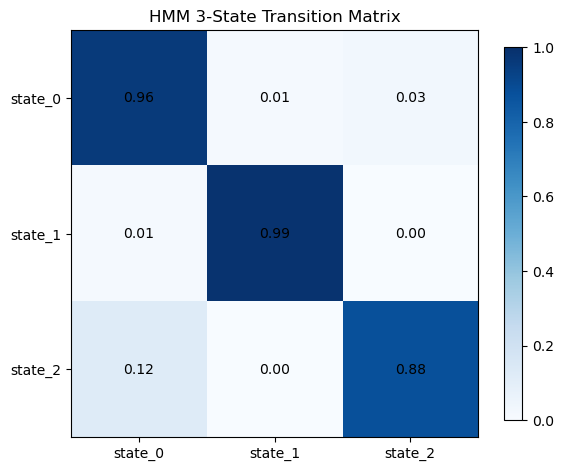

In [15]:
hmm3 = hmm_models[3]

if "mapping" not in hmm3:
    raw_labels = hmm3["model"].predict(X_bench.values)
    relabeled, mapping, means = data_helpers.relabel_states_by_macro_order(X_bench, raw_labels)
    hmm3["mapping"] = mapping
    hmm3["means"] = means

T3, order3 = data_helpers.reorder_transition_matrix(hmm3)
display(T3)

dur3 = data_helpers.implied_state_durations(T3)
display(dur3)

data_helpers.plot_transition_matrix(T3, title="HMM 3-State Transition Matrix")

In [16]:
regime_panel_full = data_helpers.make_regime_panel(X_bench, hmm3)
display(regime_panel_full.head())
display(regime_panel_full.tail())

,growth,rates_pressure,stress,state,p_state_0,p_state_1,p_state_2
date,,,,,,,
2015-05-01,0.250357,-0.157632,0.064364,0,1.000000,1.844364e-46,6.294102e-48
2015-05-08,0.297021,-0.068270,0.639529,0,0.999001,7.777622e-05,9.207999e-04
2015-05-15,0.039502,-0.034480,0.449829,0,0.999340,1.102730e-04,5.501462e-04
2015-05-22,-0.138421,0.004524,0.387080,0,0.999176,3.117478e-04,5.124875e-04
2015-05-29,-0.294907,-0.101015,0.133351,0,0.998559,1.116903e-03,3.245694e-04


,growth,rates_pressure,stress,state,p_state_0,p_state_1,p_state_2
date,,,,,,,
2026-01-30,0.581064,-0.013692,-0.266149,0,0.999569,0.000021,0.000410
2026-02-06,-0.513366,-0.080765,-0.049563,0,0.969772,0.000007,0.030222
2026-02-13,-0.765823,-0.494528,0.491179,0,0.597745,0.000001,0.402254
2026-02-20,0.057639,-0.429597,0.462238,0,0.581561,0.000002,0.418437
2026-02-27,0.034139,-0.632517,0.573092,0,0.506908,0.000043,0.493049


## 2.3 Realtime Evaluation

In [17]:
probs_oos_3, meta_oos_3, fitted_oos_3 = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=3,
    min_train=156,
    refit_every=1,          # change to 4 if this is slow
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

display(probs_oos_3.head())
display(probs_oos_3.tail())

Model is not converging.  Current: -208.52630322387287 is not greater than -208.5258844504899. Delta is -0.00041877338296103517
Model is not converging.  Current: -171.5846595183084 is not greater than -171.5843968878086. Delta is -0.00026263049980457254
Model is not converging.  Current: -172.08314754166813 is not greater than -172.08287372543768. Delta is -0.00027381623044675507
Model is not converging.  Current: -172.45595216487604 is not greater than -172.45562416609872. Delta is -0.0003279987773225912
Model is not converging.  Current: -175.49558448268587 is not greater than -175.49551072043576. Delta is -7.376225011057613e-05
Model is not converging.  Current: -195.3750479143494 is not greater than -195.37466933515876. Delta is -0.00037857919065231727
Model is not converging.  Current: -221.47942833857567 is not greater than -221.47928779478465. Delta is -0.0001405437910193541
Model is not converging.  Current: -175.92881149772026 is not greater than -175.92875716549682. Delta is

,p_state_0,p_state_1,p_state_2,state
2018-04-20,1.156605e-03,0.998843,7.147095e-31,1
2018-04-27,3.340616e-43,1.000000,3.371244e-54,1
2018-05-04,1.640059e-16,1.000000,4.928604e-30,1
2018-05-11,5.078050e-42,1.000000,5.045172e-56,1
2018-05-18,1.566855e-04,0.999843,9.726240e-34,1


,p_state_0,p_state_1,p_state_2,state
2026-01-30,0.998151,0.001479,0.000370,0
2026-02-06,0.996655,0.000799,0.002546,0
2026-02-13,0.758292,0.000144,0.241563,0
2026-02-20,0.873001,0.000133,0.126866,0
2026-02-27,0.506908,0.000043,0.493049,0


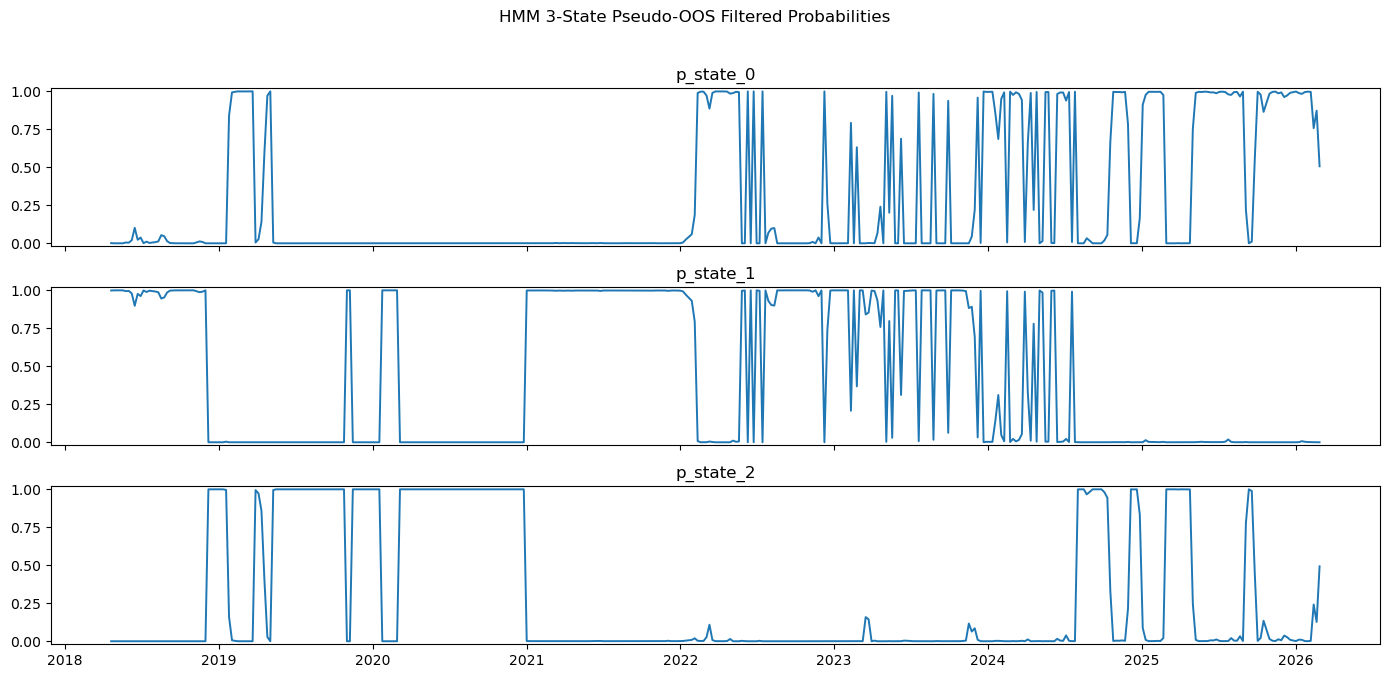

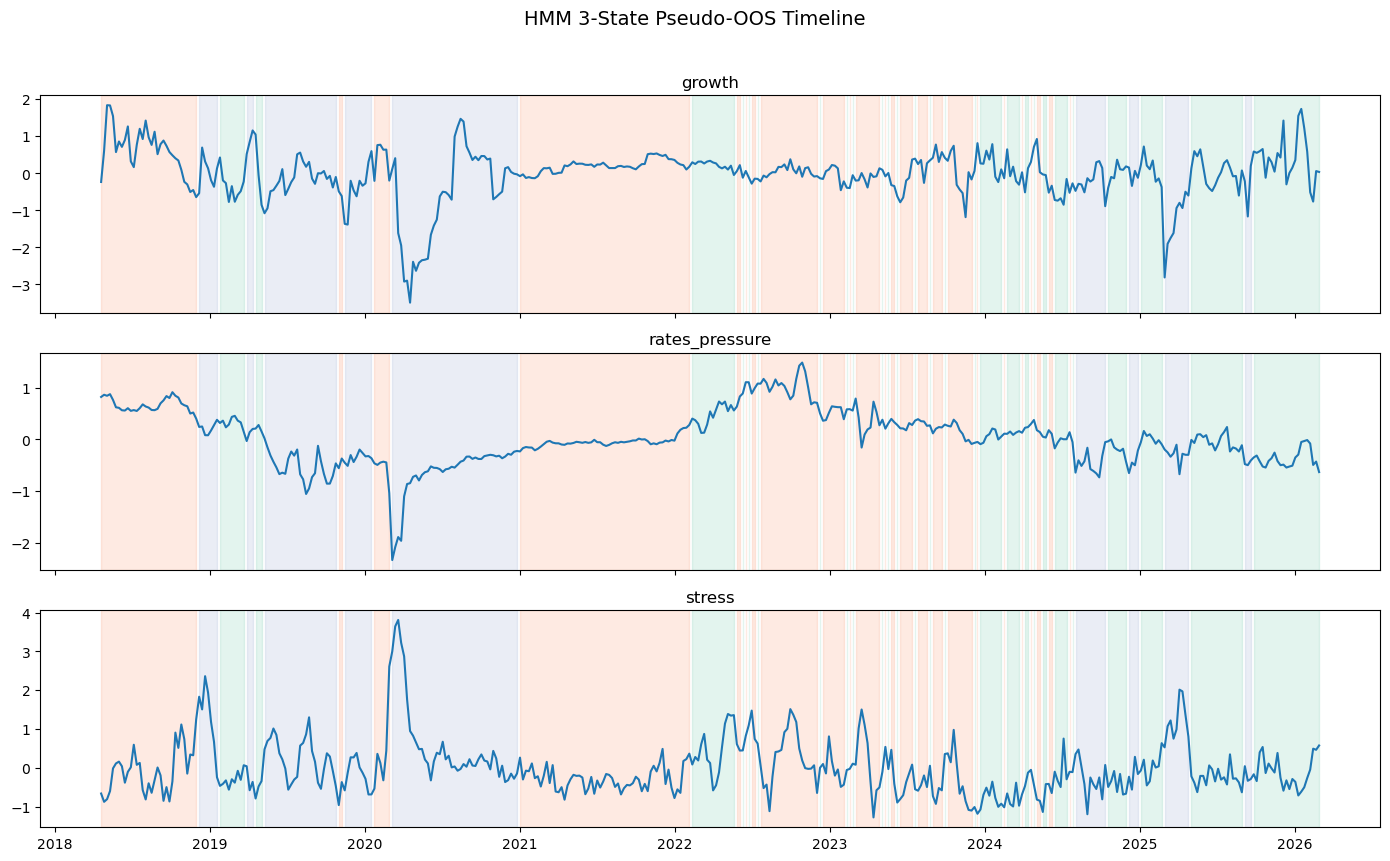

In [18]:
data_helpers.plot_oos_state_probs(probs_oos_3, title="HMM 3-State Pseudo-OOS Filtered Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3, title="HMM 3-State Pseudo-OOS Timeline")

In [19]:
compare_states = pd.DataFrame({
    "full_sample_state": hmm3["labels"].reindex(probs_oos_3.index),
    "oos_filtered_state": probs_oos_3["state"]
}).dropna()

compare_states["match"] = (
    compare_states["full_sample_state"].astype(int) ==
    compare_states["oos_filtered_state"].astype(int)
)

match_rate = compare_states["match"].mean()
print("State match rate:", round(match_rate, 4))

display(pd.crosstab(
    compare_states["full_sample_state"],
    compare_states["oos_filtered_state"],
    normalize="index"
))

State match rate: 0.5693


oos_filtered_state,0,1,2
full_sample_state,,,
0,0.391705,0.341014,0.267281
1,0.248227,0.702128,0.049645
2,0.000000,0.056604,0.943396


In [20]:
oos_state_summary = data_helpers.summarize_state_sequence(probs_oos_3["state"])
display(oos_state_summary)

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,120,0.291971,4.444444,1.0,23,27
1,176,0.428224,7.333333,2.0,58,24
2,115,0.279805,12.777778,9.0,43,9


In [21]:
switches_oos_3 = data_helpers.regime_switch_table(probs_oos_3["state"])
display(switches_oos_3.head(20))

,date,state,prev_state,switch
0,2018-04-20,1,NaN,True
1,2018-12-07,2,1.0,True
2,2019-01-25,0,2.0,True
3,2019-03-29,2,0.0,True
4,2019-04-19,0,2.0,True
5,2019-05-10,2,0.0,True
6,2019-11-01,1,2.0,True
7,2019-11-15,2,1.0,True
8,2020-01-24,1,2.0,True
9,2020-03-06,2,1.0,True


### 2 State Trial

Model is not converging.  Current: -211.57279522952774 is not greater than -211.57278106055315. Delta is -1.4168974587391858e-05
Model is not converging.  Current: -211.5728106045556 is not greater than -211.5727633377595. Delta is -4.726679608779705e-05
Model is not converging.  Current: -211.57288534598092 is not greater than -211.57273739665857. Delta is -0.00014794932235417946
Model is not converging.  Current: -214.39018903554572 is not greater than -214.3901746669055. Delta is -1.4368640222528484e-05
Model is not converging.  Current: -214.3901930351163 is not greater than -214.39017094494253. Delta is -2.2090173786182277e-05
Model is not converging.  Current: -214.39024946582174 is not greater than -214.39014868752093. Delta is -0.00010077830080490457
Model is not converging.  Current: -214.41099557639535 is not greater than -214.41092711119035. Delta is -6.84652050040313e-05
Model is not converging.  Current: -241.3156860939611 is not greater than -241.31567021563728. Delta is 

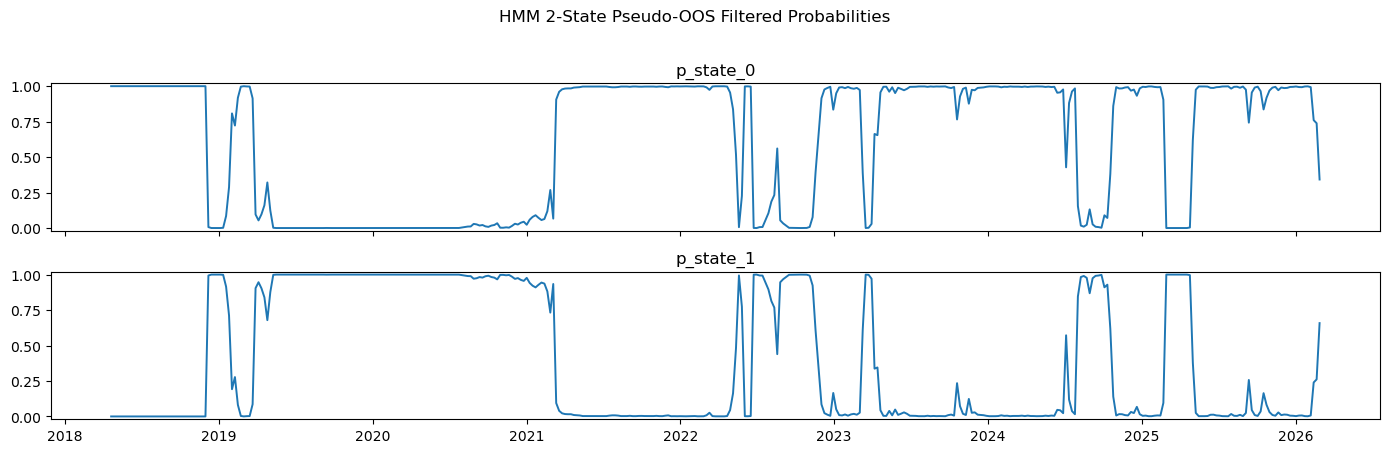

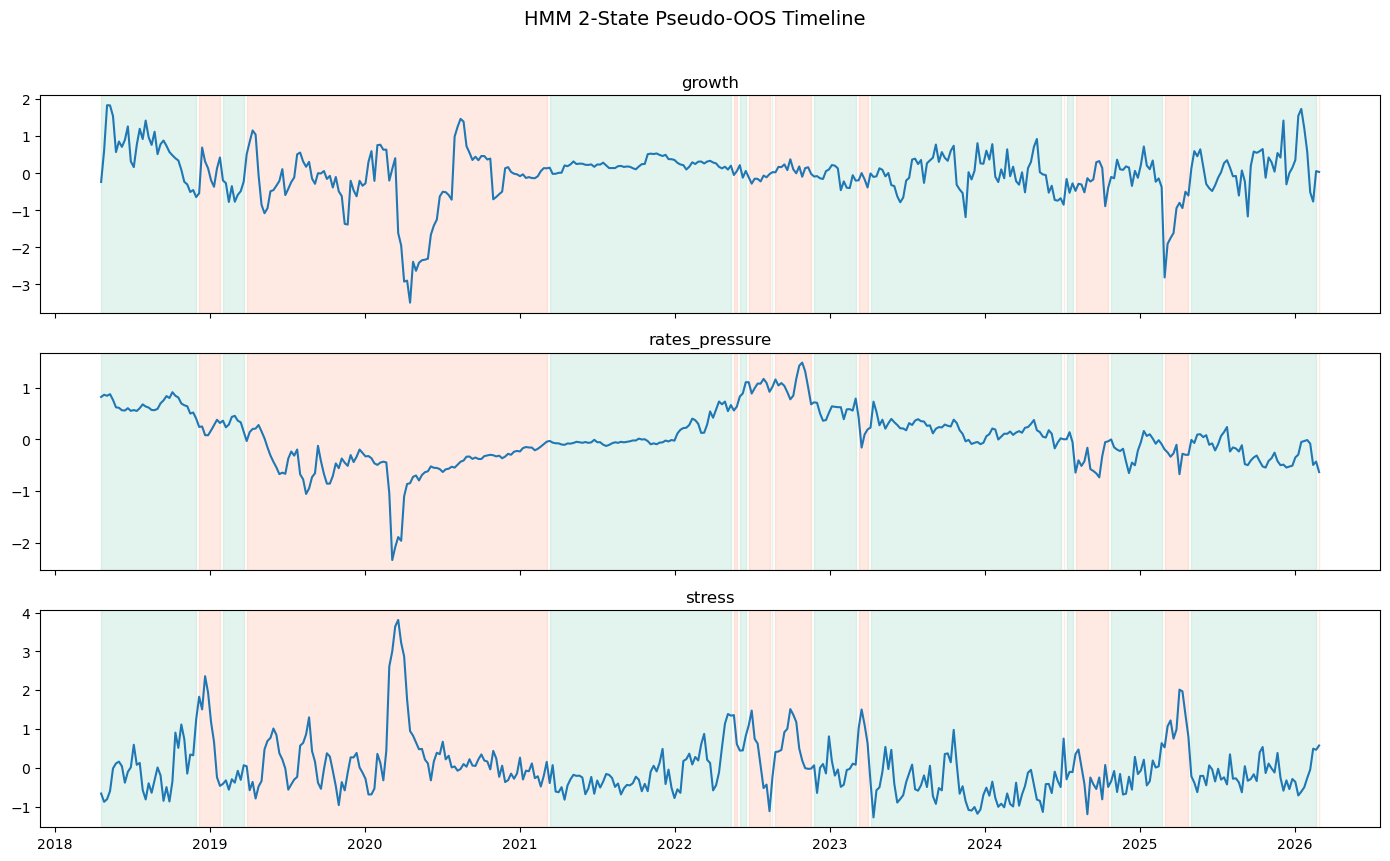

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,251,0.610706,25.1,16.5,65,10
1,160,0.389294,16.0,8.0,102,10


In [23]:
probs_oos_2, meta_oos_2, fitted_oos_2 = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=2,
    min_train=156,
    refit_every=1,
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

data_helpers.plot_oos_state_probs(probs_oos_2, title="HMM 2-State Pseudo-OOS Filtered Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_2, title="HMM 2-State Pseudo-OOS Timeline")
display(data_helpers.summarize_state_sequence(probs_oos_2["state"]))

## 3 States slower refit trial

Model is not converging.  Current: -172.08314754166813 is not greater than -172.08287372543768. Delta is -0.00027381623044675507
Model is not converging.  Current: -222.08273871730745 is not greater than -222.0826563934141. Delta is -8.23238933378434e-05
Model is not converging.  Current: -174.56913754315707 is not greater than -174.568832269119. Delta is -0.0003052740380553587
Model is not converging.  Current: -177.5815937196147 is not greater than -177.58151364575525. Delta is -8.007385943642475e-05
Model is not converging.  Current: -225.6178182511683 is not greater than -225.61774122424106. Delta is -7.702692724365079e-05
Model is not converging.  Current: -177.68301230422122 is not greater than -177.68245408140112. Delta is -0.0005582228201035377
Model is not converging.  Current: -180.6288447783682 is not greater than -180.6285686051266. Delta is -0.0002761732416161067
Model is not converging.  Current: -180.62876447776284 is not greater than -180.62856829451175. Delta is -0.000

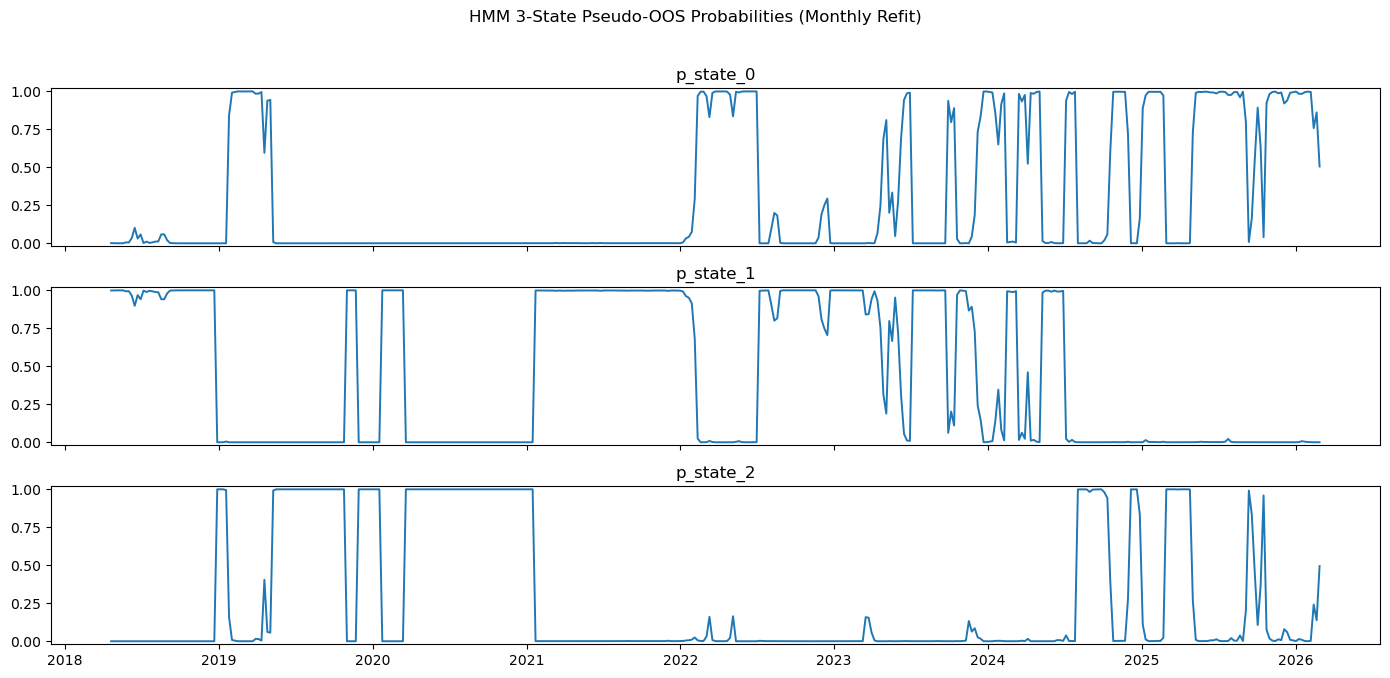

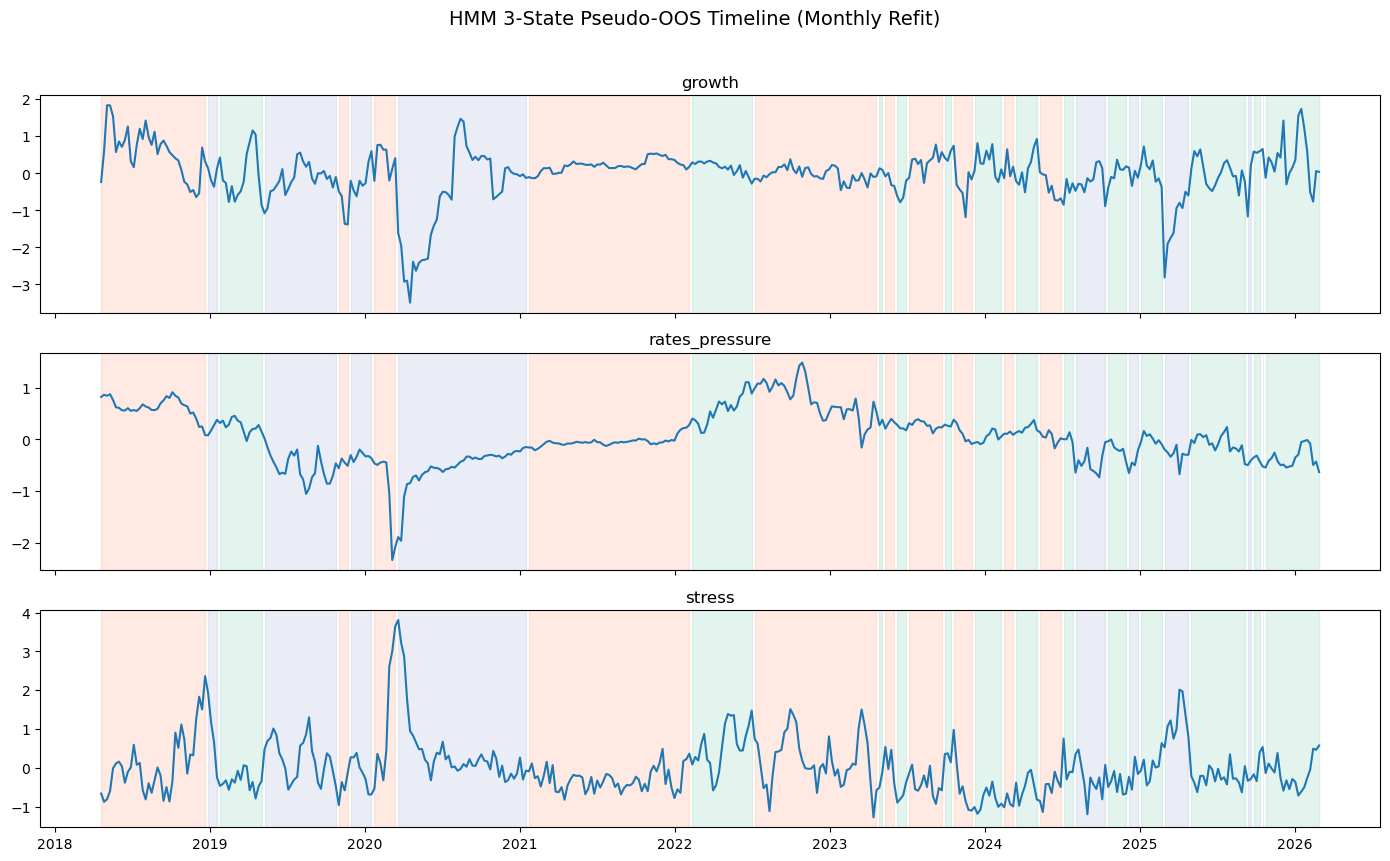

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,123,0.299270,9.461538,8.0,21,13
1,180,0.437956,18.000000,8.0,55,10
2,108,0.262774,12.000000,8.0,44,9


In [24]:
probs_oos_3_m, meta_oos_3_m, fitted_oos_3_m = data_helpers.expanding_filtered_hmm(
    X=X_model_3,
    k=3,
    min_train=156,
    refit_every=4,   # refit every 4 weeks
    covariance_type="diag",
    seeds=range(10),
    n_iter=1000,
    tol=1e-4,
)

data_helpers.plot_oos_state_probs(probs_oos_3_m, title="HMM 3-State Pseudo-OOS Probabilities (Monthly Refit)")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3_m, title="HMM 3-State Pseudo-OOS Timeline (Monthly Refit)")
display(data_helpers.summarize_state_sequence(probs_oos_3_m["state"]))

In [25]:
## Probability smoothing before hard assignment
def smooth_state_probs(probs_oos, window=3):
    prob_cols = [c for c in probs_oos.columns if c.startswith("p_state_")]
    out = probs_oos.copy()
    out[prob_cols] = out[prob_cols].rolling(window=window, min_periods=1).mean()
    out["state"] = out[prob_cols].values.argmax(axis=1)
    return out

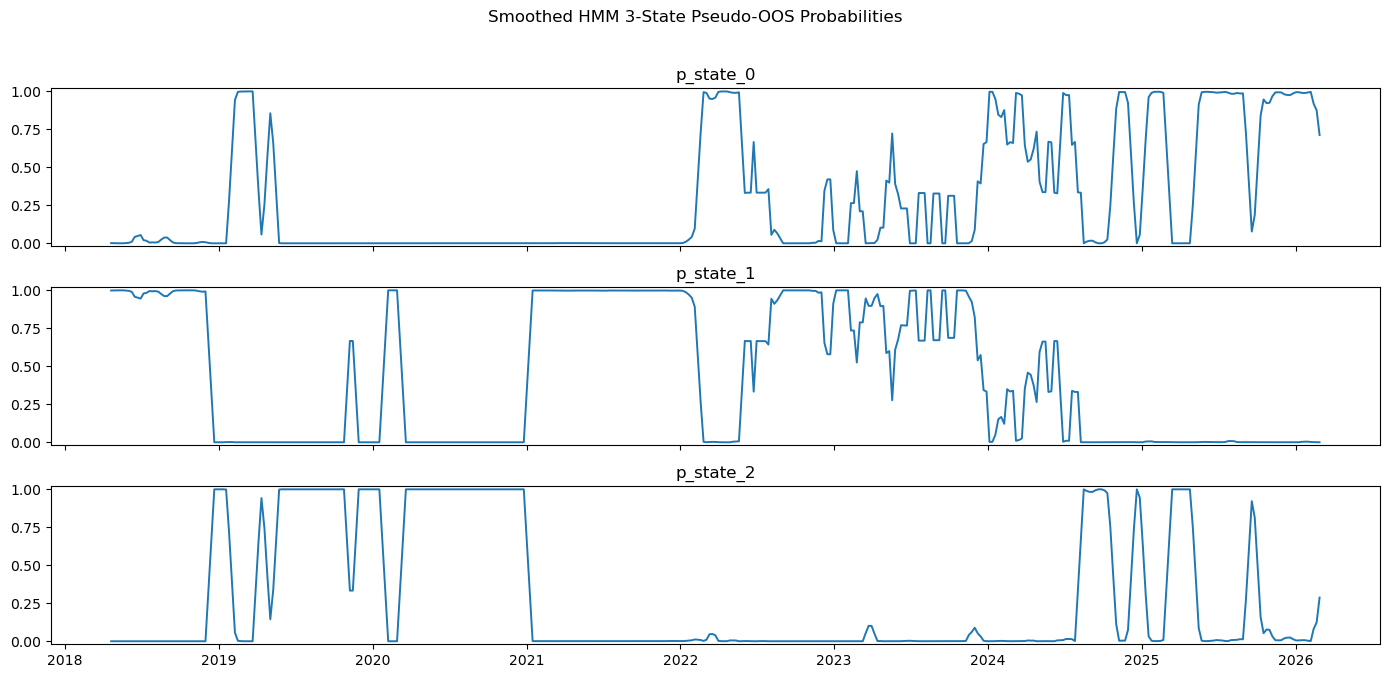

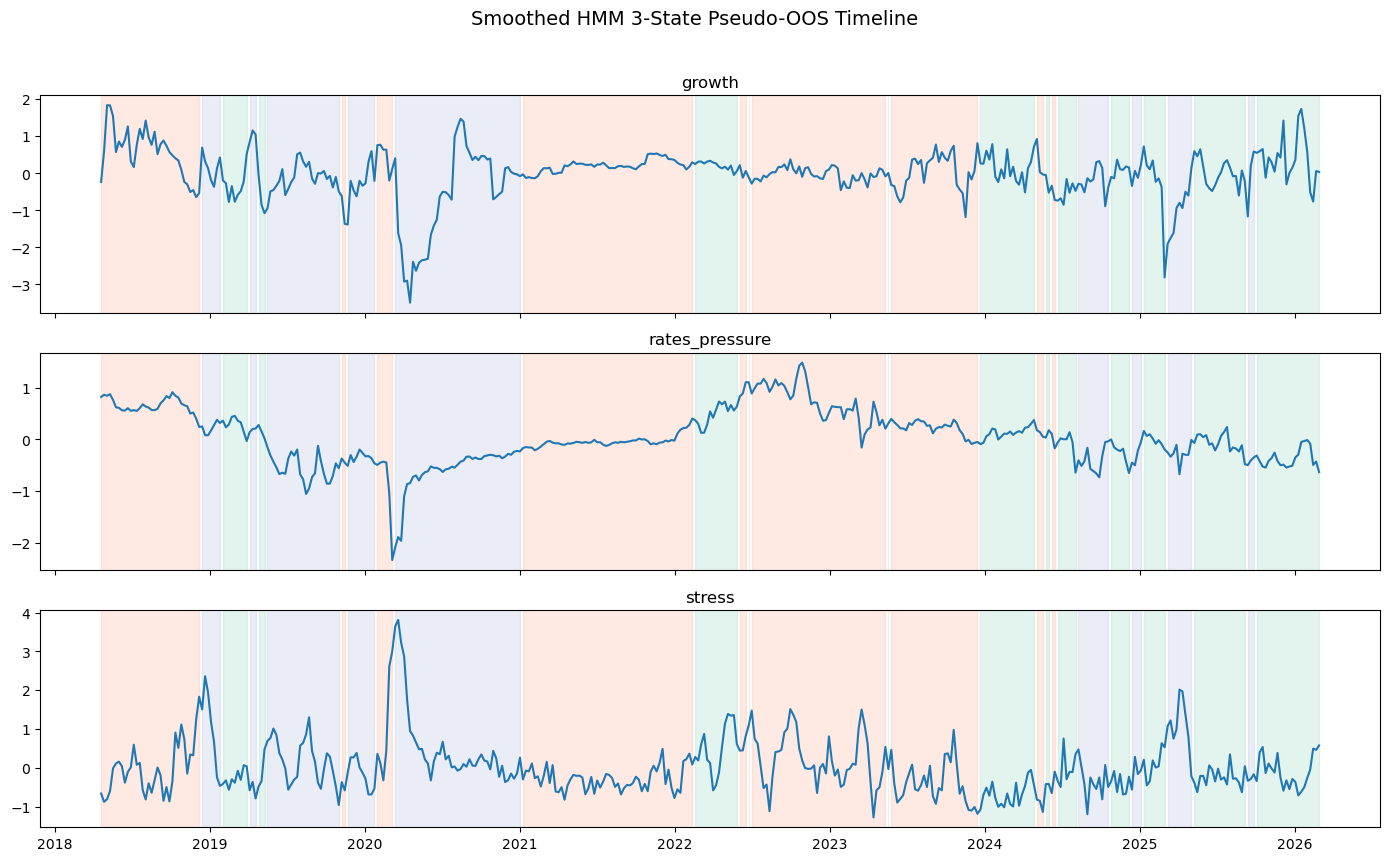

,n_obs,occupancy,avg_duration,median_duration,max_duration,n_runs
state,,,,,,
0,112,0.272506,9.333333,7.5,22,12
1,184,0.447689,20.444444,6.0,58,9
2,115,0.279805,12.777778,9.0,43,9


In [26]:
probs_oos_3_s = smooth_state_probs(probs_oos_3, window=3)

data_helpers.plot_oos_state_probs(probs_oos_3_s, title="Smoothed HMM 3-State Pseudo-OOS Probabilities")
data_helpers.plot_oos_state_timeline(X_model_3, probs_oos_3_s, title="Smoothed HMM 3-State Pseudo-OOS Timeline")
display(data_helpers.summarize_state_sequence(probs_oos_3_s["state"]))

,p_stress,stress_flag_50,stress_flag_70
2026-01-30,0.000370,0,0
2026-02-06,0.002546,0,0
2026-02-13,0.241563,0,0
2026-02-20,0.126866,0,0
2026-02-27,0.493049,0,0


<Axes: title={'center': 'Pseudo-OOS Stress Probability'}>

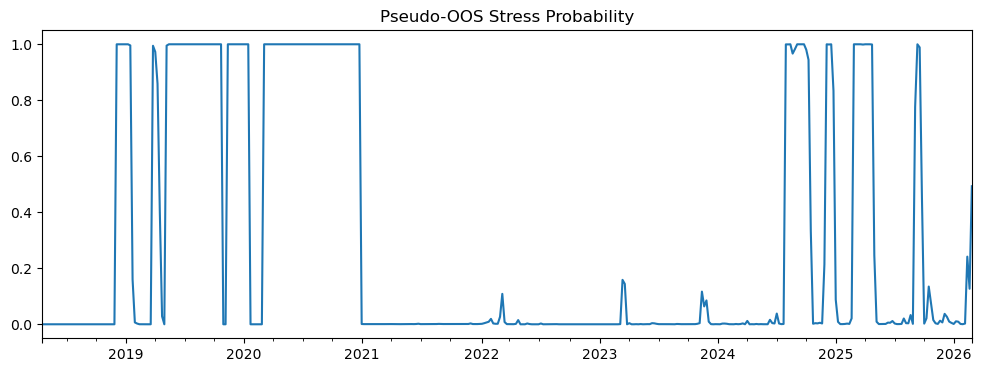

In [27]:
stress_monitor = pd.DataFrame(index=probs_oos_3.index)
stress_monitor["p_stress"] = probs_oos_3["p_state_2"]   # assuming state_2 is the stress state
stress_monitor["stress_flag_50"] = (stress_monitor["p_stress"] > 0.50).astype(int)
stress_monitor["stress_flag_70"] = (stress_monitor["p_stress"] > 0.70).astype(int)

display(stress_monitor.tail())
stress_monitor["p_stress"].plot(figsize=(12, 4), title="Pseudo-OOS Stress Probability")

## 2.6 Interpretation

## 2.7 Model Enriching